# Исследование объявлений о продаже квартир

В нашем распоряжении данные сервиса Яндекс Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. Нужно научиться определять рыночную стоимость объектов недвижимости. Для этого проведем исследовательский анализ данных и установим параметры, влияющие на цену объектов. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность.

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта и других объектов — эти данные автоматически получены из геосервисов. Количество парков и водоёмов также заполняется без участия пользователя.

Описание данных:
- airports_nearest — расстояние до ближайшего аэропорта в метрах (м)
- balcony — число балконов
- ceiling_height — высота потолков (м)
- cityCenters_nearest — расстояние до центра города (м)
- days_exposition — сколько дней было размещено объявление (от публикации до снятия)
- first_day_exposition — дата публикации
- floor — этаж
- floors_total — всего этажей в доме
- is_apartment — апартаменты (булев тип)
- kitchen_area — площадь кухни в квадратных метрах (м²)
- last_price — цена на момент снятия с публикации
- living_area — жилая площадь в квадратных метрах (м²)
- locality_name — название населённого пункта
- open_plan — свободная планировка (булев тип)
- parks_around3000 — число парков в радиусе 3 км
- parks_nearest — расстояние до ближайшего парка (м)
- ponds_around3000 — число водоёмов в радиусе 3 км
- ponds_nearest — расстояние до ближайшего водоёма (м)
- rooms — число комнат
- studio — квартира-студия (булев тип)
- total_area — общая площадь квартиры в квадратных метрах (м²)
- total_images — число фотографий квартиры в объявлении

### Первичный анализ данных

In [1]:
#Импорт необходимых библиотек
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Загружаю данные из csv-файла в датафрейм c помощью библиотеки pandas и сохраняю их в переменную data.
data = pd.read_csv('/datasets/real_estate_data.csv', sep='\t')

In [3]:
#Вывожу первые 20 строк датафрейма data на экран
pd.set_option('display.max_columns', None)
data.head(20)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.00,8,NaN,False,False,25.00,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,NaN,11.0,18.60,1,NaN,False,False,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,NaN,5.0,34.30,4,NaN,False,False,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,False,False,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.00,13,NaN,False,False,41.00,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
5,10,2890000.0,30.40,2018-09-10T00:00:00,1,NaN,12.0,14.40,5,NaN,False,False,9.10,NaN,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0
6,6,3700000.0,37.30,2017-11-02T00:00:00,1,NaN,26.0,10.60,6,NaN,False,False,14.40,1.0,посёлок Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0
7,5,7915000.0,71.60,2019-04-18T00:00:00,2,NaN,24.0,NaN,22,NaN,False,False,18.90,2.0,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN
8,20,2900000.0,33.16,2018-05-23T00:00:00,1,NaN,27.0,15.43,26,NaN,False,False,8.81,NaN,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0
9,18,5400000.0,61.00,2017-02-26T00:00:00,3,2.50,9.0,43.60,7,NaN,False,False,6.50,2.0,Санкт-Петербург,50898.0,15008.0,0.0,NaN,0.0,NaN,289.0


In [4]:
#Вывожу основную информацию о датафрейме 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

array([[<AxesSubplot:title={'center':'total_images'}>,
        <AxesSubplot:title={'center':'last_price'}>,
        <AxesSubplot:title={'center':'total_area'}>,
        <AxesSubplot:title={'center':'rooms'}>],
       [<AxesSubplot:title={'center':'ceiling_height'}>,
        <AxesSubplot:title={'center':'floors_total'}>,
        <AxesSubplot:title={'center':'living_area'}>,
        <AxesSubplot:title={'center':'floor'}>],
       [<AxesSubplot:title={'center':'kitchen_area'}>,
        <AxesSubplot:title={'center':'balcony'}>,
        <AxesSubplot:title={'center':'airports_nearest'}>,
        <AxesSubplot:title={'center':'cityCenters_nearest'}>],
       [<AxesSubplot:title={'center':'parks_around3000'}>,
        <AxesSubplot:title={'center':'parks_nearest'}>,
        <AxesSubplot:title={'center':'ponds_around3000'}>,
        <AxesSubplot:title={'center':'ponds_nearest'}>],
       [<AxesSubplot:title={'center':'days_exposition'}>, <AxesSubplot:>,
        <AxesSubplot:>, <AxesSubplot:>]], d

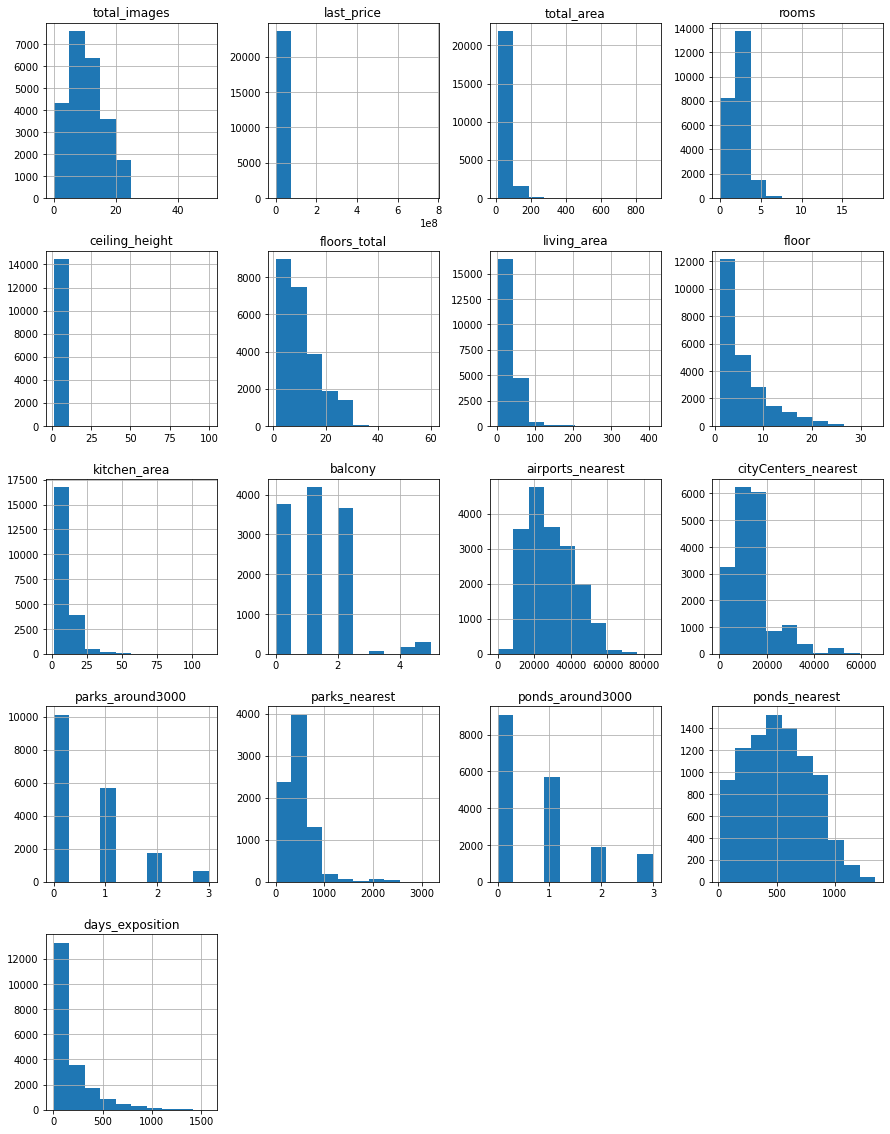

In [5]:
#Строю гистограмму для всех числовых столбцов на одном графике
data.hist(figsize=(15, 20))

**Вывод:** Были выявлены некоторые проблемы с данными. В одних столбцах обнаружены пропуски (например, в 'ceiling_height', 'is_apartment', 'balcony') и аномальные значения ('balcony', 'parks_nearest'). В других столбцах типа 'first_day_exposition', 'floors_total', 'is_apartment' указаны неверные типы данных. Кроме того, в столбце 'locality_name' были выявлены неявные дубликаты.

### Предобработка данных

In [6]:
#Определяю в каких столбцах есть пропуски
data.isna().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
cityCenters_nearest      5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64

In [7]:
#Заменяю пропуски в столбцах c категориальным типом данных на 0
l_columns_to_change_to_zero = ['balcony', 'is_apartment', 'ponds_around3000', 'parks_around3000', 'days_exposition']
for column in l_columns_to_change_to_zero:
    data[column] = data[column].fillna(0)   
#Заменяю пропуски в столбцах c количественным типом данных на соответствующее медианное значение 
l_columns_to_change_to_median = ['ceiling_height']
for column in l_columns_to_change_to_median:
    data[column] = data[column].fillna(data[column].median())
#Заменяю пропуски в столбце 'floors_total' на соответствующее медианное значение c проверкой на превышение этажности    
for i in range(len(data)):
    if data.loc[i, 'floors_total'] == 0 and data.loc[i, 'floor'] < data['floors_total'].median():
        data['floors_total'] = data['floors_total'].fillna(data['floors_total'].median())
    else:
        data['floors_total'] = data['floors_total'].fillna(0)
#Заменяю пропуски в столбце с названием населенного пункта на 'unknown'
data['locality_name'] = data['locality_name'].fillna('unknown')


**Причины возникновения пропусков**: Некоторые пропуски подразумевают отсутствие определенного параметра. Примерами этого являются, cкорее всего, столбцы 'balcony', 'is_apartment', 'ponds_around3000', 'parks_around3000', поэтому в данных столбцах пропуски были заменены нулями. Пропуски в остальных столбцах, возможно, объясняются отсутствием значений соответствующих параметров в объявлениях и были либо заменены медианными значениями, либо оставлены нетронутыми.

In [8]:
#Изменяю тип данных в некоторых столбцах
l_columns_to_change_to_int = ['floors_total', 'balcony', 'parks_around3000', 'ponds_around3000', 'days_exposition']
for column in l_columns_to_change_to_int:
    data[column] = data[column].astype(int)
#Изменяю тип данных в столбце 'first_day_exposition' с object на datetime 
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'])
#Изменяю тип данных в столбце 'is_apartment' с object на bool
data['is_apartment'] = data['is_apartment'].astype(bool)

**Причины изменения типа данных:** Правильный тип данных позволяет оптимизировать обработку и анализ данных, когда неправильный тип может приводить к ошибкам. В данном случае в столбцах 'floors_total', 'balcony', 'parks_around3000', 'ponds_around3000', 'days_exposition' был изменен тип данных с float на int, так как по смыслу в них должны содержаться целочисленные значения. В столбце 'is_apartment' тип данных был изменен на bool, так как дано, что в этом столбце булев тип данных. В столбце 'first_day_exposition' тип данных был изменен на datetime, так как это верный формат представления дат, кроме того, в дальнейшем к данному столбцу применяют функции, которые только работают только с этим типом данных (dt.weekday, dt.month и тп)

In [9]:
#Привожу список уникальных значений в столбце c названиями
data['locality_name'].unique()

array(['Санкт-Петербург', 'посёлок Шушары', 'городской посёлок Янино-1',
       'посёлок Парголово', 'посёлок Мурино', 'Ломоносов', 'Сертолово',
       'Петергоф', 'Пушкин', 'деревня Кудрово', 'Коммунар', 'Колпино',
       'поселок городского типа Красный Бор', 'Гатчина', 'поселок Мурино',
       'деревня Фёдоровское', 'Выборг', 'Кронштадт', 'Кировск',
       'деревня Новое Девяткино', 'посёлок Металлострой',
       'посёлок городского типа Лебяжье',
       'посёлок городского типа Сиверский', 'поселок Молодцово',
       'поселок городского типа Кузьмоловский',
       'садовое товарищество Новая Ропша', 'Павловск',
       'деревня Пикколово', 'Всеволожск', 'Волхов', 'Кингисепп',
       'Приозерск', 'Сестрорецк', 'деревня Куттузи', 'посёлок Аннино',
       'поселок городского типа Ефимовский', 'посёлок Плодовое',
       'деревня Заклинье', 'поселок Торковичи', 'поселок Первомайское',
       'Красное Село', 'посёлок Понтонный', 'Сясьстрой', 'деревня Старая',
       'деревня Лесколово', '

In [10]:
#Убираю неявные дубликаты в столбце с названиями
data['locality_name'] = data['locality_name'].str.replace('ё', 'е')
l_to_replace = ['поселок городского типа', 'городской поселок']
for name in l_to_replace:
    data['locality_name'] = data['locality_name'].str.replace(name, 'поселок')

### Добавление новых столбцов в таблицу

In [11]:
#Добавляю столбец с ценой одного квадратного метра
data['price_1_square_meter'] = (data['last_price']/data['total_area']).round(2)
#Добавляю столбец с номером дня недели публикации объявления
data['first_day_exposition_weekday'] = data['first_day_exposition'].dt.weekday
#Добавляю столбец с месяцем публикации объявления
data['first_day_exposition_month'] = data['first_day_exposition'].dt.month
#Добавляю столбец с годом публикации объявления
data['first_day_exposition_year'] = data['first_day_exposition'].dt.year
#Делаю список с типом этажа
l = []
for n in range(len(data['floor'])):
    if data.loc[n,'floor'] == 1:
        l.append('первый')
    elif data.loc[n,'floor'] == data.loc[n, 'floors_total']:
        l.append('последний')
    else:
        l.append('другой')
#Добавляю столбец с типом этажа
data['floor_type'] = l
data['cityCenters_nearest_in_km'] = (data['cityCenters_nearest']/1000).round()
#Проверяю, что все новые столбцы есть в датафрейме
data.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,price_1_square_meter,first_day_exposition_weekday,first_day_exposition_month,first_day_exposition_year,floor_type,cityCenters_nearest_in_km
0,20,13000000.0,108.0,2019-03-07,3,2.70,16,51.0,8,False,False,False,25.0,0,Санкт-Петербург,18863.0,16028.0,1,482.0,2,755.0,0,120370.37,3,3,2019,другой,16.0
1,7,3350000.0,40.4,2018-12-04,1,2.65,11,18.6,1,False,False,False,11.0,2,поселок Шушары,12817.0,18603.0,0,NaN,0,NaN,81,82920.79,1,12,2018,первый,19.0
2,10,5196000.0,56.0,2015-08-20,2,2.65,5,34.3,4,False,False,False,8.3,0,Санкт-Петербург,21741.0,13933.0,1,90.0,2,574.0,558,92785.71,3,8,2015,другой,14.0
3,0,64900000.0,159.0,2015-07-24,3,2.65,14,NaN,9,False,False,False,NaN,0,Санкт-Петербург,28098.0,6800.0,2,84.0,3,234.0,424,408176.10,4,7,2015,другой,7.0
4,2,10000000.0,100.0,2018-06-19,2,3.03,14,32.0,13,False,False,False,41.0,0,Санкт-Петербург,31856.0,8098.0,2,112.0,1,48.0,121,100000.00,1,6,2018,другой,8.0


### Исследовательский анализ данных

#### Изучение параметров объектов и построение отдельных гистограмм для каждого из них

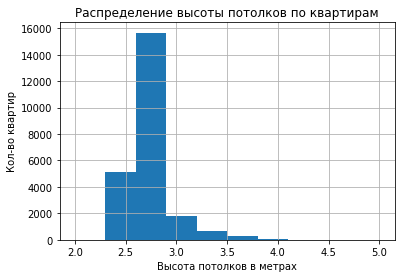

In [12]:
#Строю гистограмму для параметра 'ceiling_height'
data['ceiling_height'].hist(range=(2,5));
plt.title('Распределение высоты потолков по квартирам')
plt.ylabel('Кол-во квартир')
plt.xlabel('Высота потолков в метрах')
plt.show()

In [13]:
#Отбрасываю аномальные значения для параметра 'ceiling_height'
data = data[data['ceiling_height'] <= 5];

**Вывод:** Высота потолков находится в диапазоне от 2.4 до 4.5 м, наиболее часто встречается высота потолков, равная значению из диапазона от 2.5 до 3.0. Значения ceiling_height > 5 м были исключены как физически нереалистичные для жилых помещений (порог выбран на основе визуального анализа распределения и строительных норм РФ).

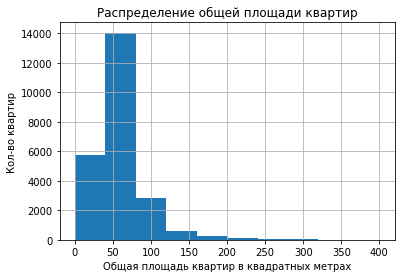

In [14]:
#Строю гистограмму для параметра 'total_area'
data['total_area'].hist(range=(0, 400));
plt.title('Распределение общей площади квартир')
plt.ylabel('Кол-во квартир')
plt.xlabel('Общая площадь квартир в квадратных метрах')
plt.show()

In [15]:
#Отбрасываю аномальные значения для параметра 'total_area'
data = data[data['total_area'] <= 500];

**Вывод:** Общая площадь находится в диапазоне от 0 до 350 м2, наиболее часто встречается общая площадь, равная значению из диапазона от 30 до 50 м2. Значения total_area > 500 м² соответствуют элитным объектам, нетипичным для массового рынка — исключены во избежание искажения анализа.

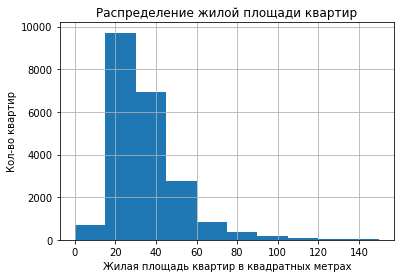

In [16]:
#Строю гистограмму для параметра 'living_area'
data['living_area'].hist(range=(0, 150));
plt.title('Распределение жилой площади квартир')
plt.ylabel('Кол-во квартир')
plt.xlabel('Жилая площадь квартир в квадратных метрах')
plt.show()

In [17]:
#Отбрасываю аномальные значения для параметра 'living_area'
data = data[data['living_area'] <= 500];

**Вывод:** Жилая площадь находится в диапазоне от 0 до 200 м2, наиболее часто встречается жилая площадь, равная значению из диапазона от 20 до 45 м2. Значения living_area > 500 м² соответствуют элитным объектам, нетипичным для массового рынка — исключены во избежание искажения анализа.

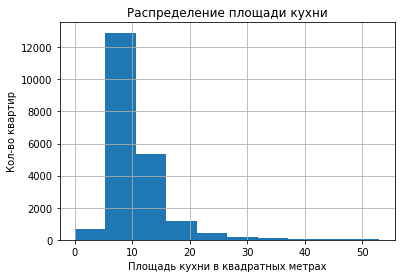

In [18]:
#Строю гистограмму для параметра 'kitchen_area'
data['kitchen_area'].hist(range=(0, 53));
plt.title('Распределение площади кухни')
plt.ylabel('Кол-во квартир')
plt.xlabel('Площадь кухни в квадратных метрах')
plt.show()

In [19]:
#Отбрасываю аномальные значения для параметра 'kitchen_area'
data = data[data['kitchen_area'] <= 100];

**Вывод:** Площадь кухни находится в диапазоне от 0 до 50 м2, наиболее часто встречается площадь кухни, равная значению из диапазона от 5 до 12 м2. Значения kitchen_area > 100 м² соответствуют элитным объектам, нетипичным для массового рынка — исключены во избежание искажения анализа.

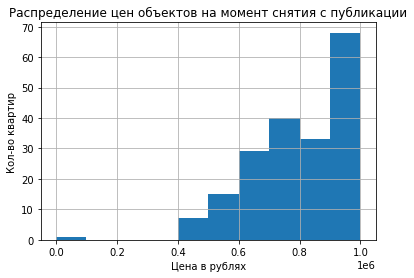

In [20]:
#Строю гистограмму для параметра 'last_price'
data['last_price'].hist(range=(0, 1e6));
plt.title('Распределение цен объектов на момент снятия с публикации')
plt.ylabel('Кол-во квартир')
plt.xlabel('Цена в рублях')
plt.show()

In [21]:
#Отбрасываю аномальные значения для параметра 'last_price'
data = data[data['last_price'] > 0];

**Вывод:** Цена объекта находится в диапазоне от 0 до 80 млн, наиболее часто встречается цена, равная значению в диапазоне от 5 млн до 10 млн. Исключаю объекты с ценой 0 рублей как физически нереалистичные.

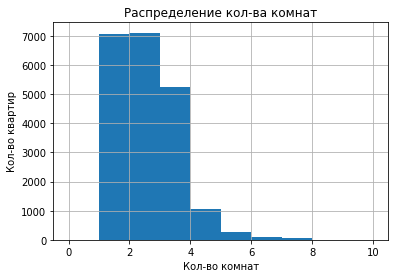

In [22]:
#Строю гистограмму для параметра 'rooms'
data['rooms'].hist(range=(0, 10));
plt.title('Распределение кол-ва комнат')
plt.ylabel('Кол-во квартир')
plt.xlabel('Кол-во комнат')
plt.show()

In [23]:
#Отбрасываю аномальные значения для параметра 'rooms'
data = data[data['rooms'] <= 8];

**Вывод:** Чаще всего в объектах 2-3 комнаты, на втором месте по популярности - 4, реже встречается большее число комнат. Исключаю объекты с числом комнат более 8 как нетипичные для массового рынка недвижимости — такие объекты относятся к элитному сегменту.

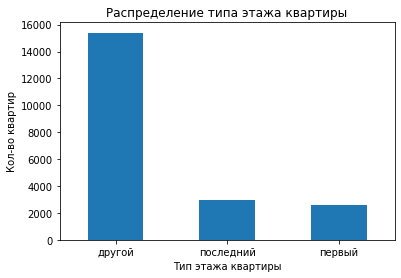

In [24]:
#Строю столбчатую диаграмму для параметра 'floor_type'
data['floor_type'].value_counts().plot(kind='bar');
plt.title('Распределение типа этажа квартиры')
plt.ylabel('Кол-во квартир')
plt.xlabel('Тип этажа квартиры')
plt.xticks(rotation=0)
plt.show()

**Вывод:** В основном объекты находятся не на первом и последнем этажах.

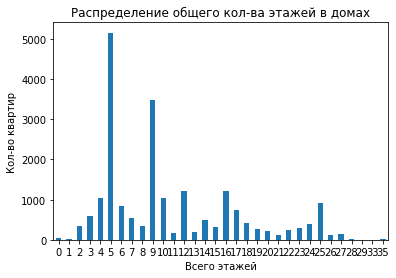

In [25]:
#Строю гистограмму для параметра 'floors_total'
data[data['floors_total'].between(0, 35)]['floors_total'].value_counts().sort_index().plot(kind='bar');
plt.title('Распределение общего кол-ва этажей в домах')
plt.ylabel('Кол-во квартир')
plt.xlabel('Всего этажей')
plt.xticks(rotation=0)
plt.show()

**Вывод:** В большинстве случаев количество этажей в домах равно 5, на втором месте кол-во этажей равно 9, чуть реже - 12, 16, 25.

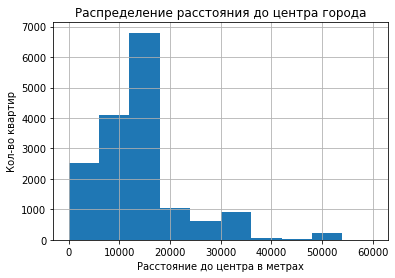

In [26]:
#Строю гистограмму для параметра 'cityCenters_nearest'
data['cityCenters_nearest'].hist(range=(0, 60000));
plt.title('Распределение расстояния до центра города')
plt.ylabel('Кол-во квартир')
plt.xlabel('Расстояние до центра в метрах')
plt.show()

**Вывод:** В основном дома находятся в 13500 м от центра города.

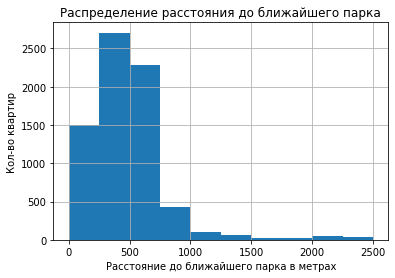

In [27]:
#Строю гистограмму для параметра 'parks_nearest'
data['parks_nearest'].hist(range=(0, 2500));
plt.title('Распределение расстояния до ближайшего парка')
plt.ylabel('Кол-во квартир')
plt.xlabel('Расстояние до ближайшего парка в метрах')
plt.show()

**Вывод:** В большинстве случаев ближайшие парки находятся в 250 м от домов. 

#### Оценка скорости продажи квартиры

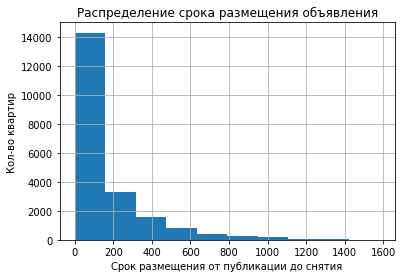

Медиана: 79.0
Среднее: 160.00692752376858


In [28]:
#Строю гистограмму по данным столбца 'days_exposition'
data['days_exposition'].hist();
plt.title('Распределение срока размещения объявления')
plt.ylabel('Кол-во квартир')
plt.xlabel('Срок размещения от публикации до снятия')
plt.show()
print('Медиана:', data['days_exposition'].median())
print('Среднее:', data['days_exposition'].mean())

**Вывод:** В среднем объекты продавались за 95 дней размещения объявления. В данном анализе лучше ориентироваться по медиане, так как некоторые выбивающиеся значения (когда квартиры продавались долго - более 200 дней) оказали большое влияние на среднее значение в столбце.

#### Определение влияния различных факторов на общую стоимость объекта

In [29]:
#Строю матрицу корреляции для выявления корреляции между различными факторами и стоимостью объекта
data.corr()

,total_images,last_price,total_area,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,price_1_square_meter,first_day_exposition_weekday,first_day_exposition_month,first_day_exposition_year,cityCenters_nearest_in_km
total_images,1.000000,0.120148,0.120240,0.096445,0.047671,0.022155,0.103138,0.037100,0.006927,NaN,NaN,0.111637,0.037273,-0.001070,-0.052280,0.030942,-0.007681,0.005890,0.000037,-0.071035,0.138790,-0.009310,0.003791,0.160738,-0.051765
last_price,0.120148,1.000000,0.670575,0.385719,0.337607,0.000796,0.589969,0.027505,0.026859,NaN,NaN,0.500212,0.006041,-0.031815,-0.239855,0.230907,-0.020060,0.233759,-0.100806,0.062528,0.775293,-0.003478,-0.005250,-0.046617,-0.240481
total_area,0.120240,0.670575,1.000000,0.772851,0.413193,-0.061688,0.935846,-0.018549,0.016959,NaN,NaN,0.597232,0.012570,-0.033887,-0.238925,0.202968,-0.017102,0.207139,-0.102387,0.096783,0.298903,-0.007176,0.006384,-0.086233,-0.239010
rooms,0.096445,0.385719,0.772851,1.000000,0.253865,-0.216467,0.851184,-0.146794,-0.009432,NaN,NaN,0.252551,-0.012118,-0.063762,-0.188151,0.149291,-0.047039,0.122545,-0.056479,0.072490,0.047727,-0.003101,0.000415,-0.054880,-0.187890
ceiling_height,0.047671,0.337607,0.413193,0.253865,1.000000,-0.081385,0.385040,-0.045341,0.054027,NaN,NaN,0.340458,-0.055884,-0.085753,-0.300934,0.247983,-0.060028,0.218005,-0.113543,0.070971,0.296108,-0.021014,-0.006318,-0.053406,-0.301212
floors_total,0.022155,0.000796,-0.061688,-0.216467,-0.081385,1.000000,-0.163286,0.670759,-0.011378,NaN,NaN,0.174658,0.183451,0.117407,0.016501,-0.154262,0.099409,-0.050192,0.043781,-0.026554,0.158191,0.008641,0.016005,0.011971,0.015938
living_area,0.103138,0.589969,0.935846,0.851184,0.385040,-0.163286,1.000000,-0.096898,0.012580,NaN,NaN,0.404519,-0.012636,-0.056639,-0.230801,0.209276,-0.047667,0.185650,-0.084216,0.088142,0.208976,-0.006401,0.000997,-0.074103,-0.230656
floor,0.037100,0.027505,-0.018549,-0.146794,-0.045341,0.670759,-0.096898,1.000000,-0.000437,NaN,NaN,0.142389,0.176858,0.080890,0.006466,-0.102979,0.072856,-0.031927,0.028790,-0.020333,0.133729,0.010134,0.018352,0.008280,0.005971
is_apartment,0.006927,0.026859,0.016959,-0.009432,0.054027,-0.011378,0.012580,-0.000437,1.000000,NaN,NaN,0.039212,0.041250,0.004415,-0.004420,0.010676,-0.022342,0.018541,0.007896,0.020538,0.038341,-0.005710,0.002870,-0.005127,-0.004365
studio,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


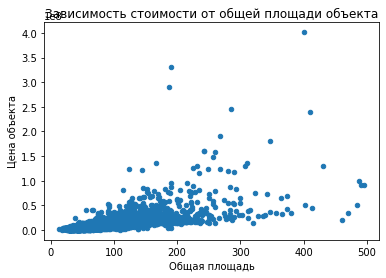

In [30]:
#Строю график влияния общей площади на стоимость объекта
data.plot(x='total_area', y='last_price', kind='scatter');
plt.title('Зависимость стоимости от общей площади объекта')
plt.ylabel('Цена объекта')
plt.xlabel('Общая площадь')
plt.show()

**Вывод:** С ростом общей площади растет и общая стоимость объекта. Это видно по графику и по коэффициенту Пирсона, равному 0,67, что указывает на умеренную положительную корреляцию.

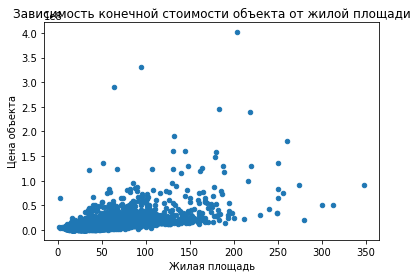

In [31]:
#Строю график зависимости конечной стоимости объекта от жилой площади
data.plot(x='living_area', y='last_price', kind='scatter');
plt.title('Зависимость конечной стоимости объекта от жилой площади')
plt.ylabel('Цена объекта')
plt.xlabel('Жилая площадь')
plt.show()

**Вывод:** С ростом жилой площади растет и общая стоимость объекта, однако зависимость не так выражена как в случае с влиянием роста общей площади на общую стоимость объекта. В данном случае коэффициент Пирсона равен 0.59, что также указывает на умеренную положительную связь

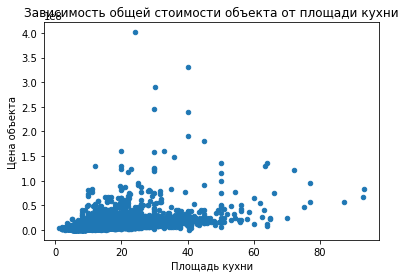

In [32]:
#Строю график зависимости общей стоимости объекта от площади кухни
data.plot(x='kitchen_area', y='last_price', kind='scatter');
plt.title('Зависимость общей стоимости объекта от площади кухни')
plt.ylabel('Цена объекта')
plt.xlabel('Площадь кухни')
plt.show()

**Вывод:** С ростом площади кухни растет и общая стоимость объекта, однако зависимость плохо выражена, так как коэффициент Пирсона равен 0.5, что указывает на слабую линейную связь.

In [33]:
#Строю сводную таблицу для выявления зависимости между общей стоимостью объекта и количеством комнат
rooms_table = data.pivot_table(index='rooms',values='last_price', aggfunc=['count', 'median','mean'])
rooms_table.columns = ['count', 'median_last_price', 'mean_last_price']
print(rooms_table.sort_values(by='median_last_price', ascending=False))

       count  median_last_price  mean_last_price
rooms                                           
7         48         22950000.0     3.044896e+07
8          9         22190000.0     4.563222e+07
6         95         18777000.0     3.040740e+07
5        276         14000000.0     2.275992e+07
4       1060          9000000.0     1.314547e+07
3       5264          6200000.0     8.100022e+06
2       7111          4790000.0     5.578126e+06
1       7068          3600000.0     3.833342e+06


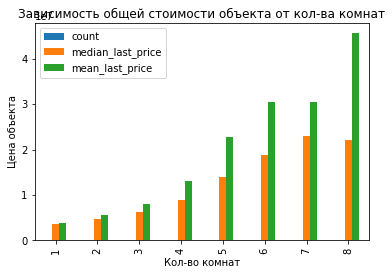

In [34]:
#Строю график зависимости общей стоимости объекта от количества комнат
rooms_table.plot.bar()
plt.title('Зависимость общей стоимости объекта от кол-ва комнат')
plt.ylabel('Цена объекта')
plt.xlabel('Кол-во комнат')
plt.show()

**Вывод:** Можно отметить, что большее количество комнат коррелирует с более высокой ценой.

In [35]:
#Строю сводную таблицу для выявления зависимости между общей стоимостью объекта и категорией этажа
floor_type_table = data.pivot_table(index='floor_type',values='last_price', aggfunc=['count','median', 'mean'])
floor_type_table.columns = ['count', 'median_last_price', 'mean_last_price']
print(floor_type_table.sort_values(by='median_last_price', ascending=False))

            count  median_last_price  mean_last_price
floor_type                                           
другой      15397          4900000.0     6.646190e+06
последний    2978          4350000.0     6.654569e+06
первый       2556          3950000.0     4.783574e+06


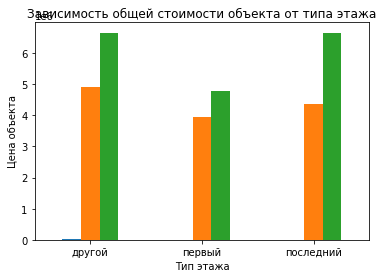

In [36]:
#Строю график зависимости общей стоимости объекта от этажа, на котором  расположен объект
floor_type_table.plot.bar(legend=False)
plt.title('Зависимость общей стоимости объекта от типа этажа')
plt.ylabel('Цена объекта')
plt.xlabel('Тип этажа')
plt.xticks(rotation=0)
plt.show()

**Вывод:** Больше всего стоят объекты, которые находятся на другом, отличном от последнего и первого, этаже. После них по стоимости идут объекты на последнем этаже, меньше всего стоят объекты на первом этаже.

In [37]:
#Строю сводную таблицу для выявления зависимости между общей стоимостью объекта и днем недели публикации объявления
weekday_table = data.pivot_table(index='first_day_exposition_weekday',values='last_price', aggfunc=['count','median','mean'])
weekday_table.columns = ['count', 'median_last_price', 'mean_last_price']
print(weekday_table.sort_values(by='median_last_price', ascending=False))

                              count  median_last_price  mean_last_price
first_day_exposition_weekday                                           
1                              3720          4764824.5     6.384604e+06
2                              3505          4750000.0     6.325742e+06
0                              3239          4700000.0     6.499768e+06
3                              3816          4700000.0     6.681894e+06
4                              3530          4600000.0     6.206744e+06
5                              1666          4600000.0     6.456739e+06
6                              1455          4600000.0     6.347397e+06


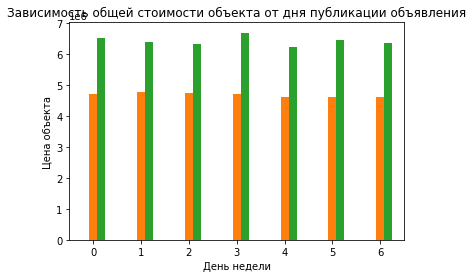

In [38]:
#Строю график зависимости общей стоимости объекта от дня недели публикации объявления
weekday_table.plot.bar(legend=False)
plt.title('Зависимость общей стоимости объекта от дня публикации объявления')
plt.ylabel('Цена объекта')
plt.xlabel('День недели')
plt.xticks(rotation=0)
plt.show()

**Вывод:** Можно отметить небольшое влияние дня недели на стоимость объектов: cо вторника по четверг стоимость объектов самая высокая, затем стоимость объектов убывает с четверга по воскресенье и чуть повышается в понедельник.

In [39]:
#Строю сводную таблицу для выявления зависимости между общей стоимостью объекта и месяцем публикации объявления
month_table = data.pivot_table(index='first_day_exposition_month',values='last_price', aggfunc=['count','median','mean'])
month_table.columns = ['count', 'median_last_price', 'mean_last_price']
print(month_table.sort_values(by='median_last_price', ascending=False))

                            count  median_last_price  mean_last_price
first_day_exposition_month                                           
12                           1331          4850000.0     6.642299e+06
4                            2141          4800000.0     6.717448e+06
9                            1822          4735000.0     6.429846e+06
2                            2300          4700000.0     6.493565e+06
3                            2266          4700000.0     6.341194e+06
11                           2163          4700000.0     6.482011e+06
1                            1259          4650000.0     6.540622e+06
7                            1476          4650000.0     6.301328e+06
8                            1544          4600000.0     6.383805e+06
10                           1930          4599500.0     5.990560e+06
5                            1132          4580000.0     6.454036e+06
6                            1567          4490000.0     6.287614e+06


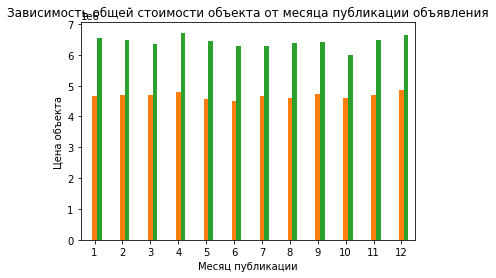

In [40]:
#Строю график зависимости общей стоимости объекта от месяца публикации объявления
month_table.plot.bar(legend=False)
plt.title('Зависимость общей стоимости объекта от месяца публикации объявления')
plt.ylabel('Цена объекта')
plt.xlabel('Месяц публикации')
plt.xticks(rotation=0)
plt.show()

**Вывод:** В целом цены по месяцам значительно не отличаются. Наиболее высокая средняя стоимость объектов наблюдается в апреле и декабре, наименьшая — в октябре.

In [41]:
#Строю сводную таблицу для выявления зависимости между общей стоимостью объекта и годом публикации объявления
year_table = data.pivot_table(index='first_day_exposition_year',values='last_price', aggfunc=['count','median','mean'])
year_table.columns = ['count', 'median_last_price','mean_last_price']
print(year_table.sort_values(by='median_last_price', ascending=False))

                           count  median_last_price  mean_last_price
first_day_exposition_year                                           
2014                         128          7640000.0     1.203140e+07
2015                        1063          5250000.0     8.203006e+06
2019                        2569          5050000.0     6.600109e+06
2018                        7248          4648500.0     5.981155e+06
2016                        2533          4550000.0     6.686764e+06
2017                        7390          4550000.0     6.342493e+06


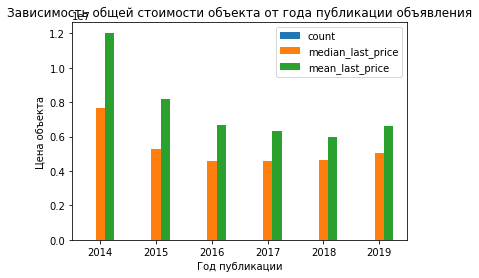

In [42]:
#Строю график зависимости общей стоимости объекта от года публикации объявления
year_table.plot.bar(legend=True)
plt.title('Зависимость общей стоимости объекта от года публикации объявления')
plt.ylabel('Цена объекта')
plt.xlabel('Год публикации')
plt.xticks(rotation=0)
plt.show()

**Вывод:** Можно отметить, что наиболее высокая стоимость объектов наблюдается в 2014, а наиболее низкая стоимость - в 2017.

**Общий вывод:** По графикам видно, что высокая цена объектов коррелирует с большей жилой и общей площадями, а также большей площадью кухни и большим числом комнат. Более того, можно заметить, что более дорогие объекты находятся на другом этаже, отличном от первого и последнего, и их чаще выставляют по вторникам, в апреле, в 2014 году.

#### Определение средней цены одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений**

In [43]:
#Определение кол-ва объявлений и расчет цены одного квадратного метра в населенных пунктах
new_table = data.pivot_table(index='locality_name', values=['days_exposition','price_1_square_meter'], aggfunc={'days_exposition':'count', 'price_1_square_meter':'mean'})
#Сортировка сводной таблицы по кол-ву объявлений и вывод 10 населенных пунктов с наибольшим кол-вом объявлений, а также расчетом цены квадратного метра в данных населенных пунктах
new_table = new_table.sort_values(by='days_exposition', ascending = False).head(10)
#Сортировка сводной таблицы по стоимости одного квадратного метра по убыванию
new_table = new_table.sort_values(by='price_1_square_meter', ascending = False)
new_table

,days_exposition,price_1_square_meter
locality_name,,
Санкт-Петербург,14029,113725.046780
Пушкин,337,103291.299110
деревня Кудрово,226,92248.477301
поселок Парголово,288,90756.002986
поселок Мурино,429,85412.816224
Петергоф,190,83754.204053
поселок Шушары,393,78535.194122
Колпино,322,75226.296398
Всеволожск,357,69029.150056


**Вывод:** Из этих данных видно, что наибольшая стоимость одного квадратного метра среди 10 населенных пунктов с наибольшим кол-вом объявлений в Санкт-Петербурге, на последнем месте по стоимости квадратного метра - Выборг.

#### Определение средней стоимости квартир в Санкт-Петербурге на разном удалении от центра**

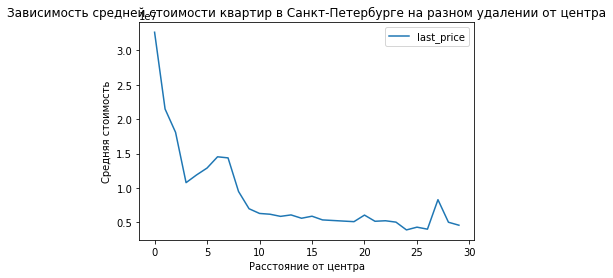

In [44]:
#Фильтрую данные для Санкт-Петербурга
stp_data = data[data['locality_name'] == 'Санкт-Петербург']
#Расчет средней стоимости квартир в Санкт-Петербурге на разном удалении от центра
stp_data = stp_data.pivot_table(index='cityCenters_nearest_in_km', values='last_price', aggfunc='mean')
#Строю график средней стоимости квартир в Санкт-Петербурге на разном удалении от центра
stp_data.plot()
plt.title('Зависимость средней стоимости квартир в Санкт-Петербурге на разном удалении от центра')
plt.ylabel('Средняя стоимость')
plt.xlabel('Расстояние от центра')
plt.xticks(rotation=0)
plt.show()

**Вывод:** По графику видно, что с увеличением расстояния от центра города стоимость квартир в Санкт-Петербурге в среднем снижается.

### Итоговый вывод

Анализ ~23699 объявлений о продаже квартир в Санкт-Петербурге и Ленинградской области позволил выявить ключевые ценовые факторы, пригодные для построения системы автоматической оценки стоимости и детектирования аномалий.

Площадь — наиболее сильный предиктор цены: общая площадь даёт коэффициент Пирсона 0.67, жилая — 0.59, площадь кухни — 0.50. Эти три признака должны составлять основу любой ценовой модели.

Этаж оказывает систематическое влияние: квартиры на первом этаже стоят дешевле квартир на средних этажах, квартиры на последнем этаже занимают промежуточную позицию. При обнаружении аномалий объявления на первом этаже следует сравнивать отдельно от остальных.

Расположение критично: цена квадратного метра в Санкт-Петербурге — наивысшая среди 10 крупнейших населённых пунктов выборки; в Выборге — наименьшая. Внутри Петербурга прослеживается устойчивая отрицательная зависимость цены от расстояния до центра — объекты в пределах центральных зон оцениваются значительно выше.

Скорость продажи: медианный срок экспозиции составил 95 дней. Объявления, висящие значительно дольше медианы, являются кандидатами на проверку — возможна некорректная цена или мошенническая активность.

Временные факторы дают слабый, но измеримый сигнал: пик средних цен — апрель и декабрь, минимум — октябрь; 2014 год показал наивысшие медианные цены, 2017 — наименьшие, что соответствует общей динамике рынка недвижимости РФ в этот период.

Практический вывод для модели: приоритетные признаки — total_area, living_area, rooms, cityCenters_nearest, floor_type. Объявления с ценой, отклоняющейся более чем на 2σ от медианы по сегменту (район × тип этажа × число комнат), следует автоматически направлять на ручную проверку как потенциально аномальные.